## Testing the newly obtained Mean Field

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook is used to check the newly obtained MF containing FS and RS neurons. 

We are going to:
1) select the best parameter sets from the transfer function fitting procedures,
2) simulate the corresponding mean field models,
3) compare the results with those from the NN stimulated with the same protocol.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [3]:
from ntmf.neurons import setting_simulation_Brian, voltage_clamp_synapse, AdEx_eqs
from ntmf.network import network_creation, extracting_pop_freq_and_std, extracting_single_pop_freq_and_std
from utils.Plots_helper import *
from ntmf.meanfield import simulate_MF_FS_RS
from ntmf.config import get_params_model_SI, get_network_config, adding_K_params


In [4]:
from ntmf.transfer_function import *

In [5]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [6]:
fig_name = 'Testing_MF_v0'

## Setting up the neuron model

In [7]:
data_folder = '../../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

neuron_model = 'FS'
params_SI_FS = get_params_model_SI(neuron_model = neuron_model,
                             json_file_name = os.path.join(data_folder, neuron_model + '.json'))

neuron_model = 'RS'
params_SI_RS = get_params_model_SI(neuron_model = neuron_model,
                             json_file_name = os.path.join(data_folder, neuron_model + '.json'))

In [8]:
params_SI_FS, params_SI_RS

({'C_m': 2.0000000000000003e-10,
  'g_L': 1e-08,
  'E_L': -0.065,
  'a': 0.0,
  'b': 0.0,
  'tau_w': 0.001,
  'V_th': -0.048,
  'Delta_T': 0.0005,
  'V_reset': -0.065,
  'V_peak': 0.0,
  't_ref': 0.005,
  'E_e': 0.0,
  'Q_e': 1.5000000000000002e-09,
  'E_i': -0.08,
  'Q_i': 5e-09,
  'tau_syn': 0.005},
 {'C_m': 2.0000000000000003e-10,
  'g_L': 1e-08,
  'E_L': -0.065,
  'a': 0.0,
  'b': 1.0000000000000002e-10,
  'tau_w': 0.5,
  'V_th': -0.05,
  'Delta_T': 0.002,
  'V_reset': -0.065,
  'V_peak': 0.0,
  't_ref': 0.005,
  'E_e': 0.0,
  'Q_e': 1.5000000000000002e-09,
  'E_i': -0.08,
  'Q_i': 5e-09,
  'tau_syn': 0.005})

## Reading in network configuration

In [9]:
#network_config_folder = '../../config/'
network_config_folder = ''
network_file_name = 'network_config_file_val.json'

In [10]:
network_config = get_network_config(json_file_name =  os.path.join(network_config_folder, network_file_name))

In [11]:
network_config

{'metainfo': 'Network config file -- v0',
 'network_composition': {'tot_neurons': 10000,
  'FS_neuron': 2000,
  'RS_neuron': 8000,
  'conn_prob': 0.05},
 'external_input': {'N_external_exc': 8000,
  'N_external_inh': 2000,
  'conn_prob': 0.05,
  'Q_e': 1.5,
  'Q_i': 5},
 'rates': {'freq_exc_FS': 2,
  'freq_exc_RS': 2,
  'freq_inh_FS': 2,
  'freq_inh_RS': 2,
  'background_freq': 0.3},
 'units': {'freq_exc_FS': 'Hz',
  'freq_exc_RS': 'Hz',
  'freq_inh_FS': 'Hz',
  'freq_ing_RS': 'Hz',
  'background_freq': 'Hz',
  'Q_e': 'nS',
  'Q_i': 'nS'}}

In [12]:
params_SI_FS = adding_K_params(neuron_params = params_SI_FS,
                            network_config = network_config)

params_SI_RS = adding_K_params(neuron_params = params_SI_RS,
                            network_config = network_config)

In [13]:
params_SI_FS, params_SI_RS

({'C_m': 2.0000000000000003e-10,
  'g_L': 1e-08,
  'E_L': -0.065,
  'a': 0.0,
  'b': 0.0,
  'tau_w': 0.001,
  'V_th': -0.048,
  'Delta_T': 0.0005,
  'V_reset': -0.065,
  'V_peak': 0.0,
  't_ref': 0.005,
  'E_e': 0.0,
  'Q_e': 1.5000000000000002e-09,
  'E_i': -0.08,
  'Q_i': 5e-09,
  'tau_syn': 0.005,
  'K_e': 400.0,
  'K_i': 100.0},
 {'C_m': 2.0000000000000003e-10,
  'g_L': 1e-08,
  'E_L': -0.065,
  'a': 0.0,
  'b': 1.0000000000000002e-10,
  'tau_w': 0.5,
  'V_th': -0.05,
  'Delta_T': 0.002,
  'V_reset': -0.065,
  'V_peak': 0.0,
  't_ref': 0.005,
  'E_e': 0.0,
  'Q_e': 1.5000000000000002e-09,
  'E_i': -0.08,
  'Q_i': 5e-09,
  'tau_syn': 0.005,
  'K_e': 400.0,
  'K_i': 100.0})

## Reading in TS params

In [14]:
#with open('../fitting/results_FS/mask_best_fitting_FS_v1.json', 'r') as f:
#            data_FS = json.load(f)
#
#with open('../fitting/results_RS/best_fitting_RS_v1.json', 'r') as f:
#            data_RS = json.load(f)

with open('FS_MF_params.json', 'r') as f:
            data_FS = json.load(f)

with open('RS_MF_params.json', 'r') as f:
            data_RS = json.load(f)

In [15]:
FS_idx = 0
print(f'FS TF params: {data_FS[FS_idx]}')

RS_idx = 0
print(f'RS TF params: {data_RS[RS_idx]}')

FS TF params: {'alpha': 1.165, 'mean_error': 6.692889852581648, 'polynomial_params': [-0.049000450828402375, 0.0003021654913283916, 0.0033465050912907454, 0.015193327502109461, 0.0011952282885883602, 0.020792211918282302, 0.012572054942131386, 0.0025600025790218865, -0.011563518278519851, 0.016910362670219656]}
RS TF params: {'alpha': 1.17, 'mean_error': 0.24510519542313824, 'polynomial_params': [-0.049931201732962935, 0.0071595546569219425, 0.013100406747808007, -0.004352889306155215, 0.0004179650649910982, 0.005142164218545077, 0.0010674726634884075, -0.0003438313493211277, 0.003165730857380371, 0.002352289709513112]}


In [17]:
#network_config['rates']['background_freq']

In [18]:
# --- time definition ---
T = 1.0
dt = 1e-3
time = np.arange(0, T, dt)

# --- external drive ---
driving_input = {
    'excitatory': {
    'FS': np.ones_like(time) * (network_config['rates']['freq_exc_FS']),
    'RS': np.ones_like(time) * (network_config['rates']['freq_exc_RS'])
    },
    'inhibitory': {
    'FS': np.ones_like(time) * (network_config['rates']['freq_inh_FS']),
    'RS': np.ones_like(time) * (network_config['rates']['freq_inh_RS'])
    }
}

rates = simulate_MF_FS_RS(
    time = time,
    neuron_models = ['FS', 'RS'],
    params = {'FS': params_SI_FS, 'RS': params_SI_RS},
    poly_params = {'FS': data_FS[FS_idx]['polynomial_params'],
                   'RS': data_RS[RS_idx]['polynomial_params']},
    alphas = {'FS': data_FS[FS_idx]['alpha'],
             'RS': data_RS[RS_idx]['alpha']},
    network_config = network_config,
    driving_input = driving_input
)

### Plots

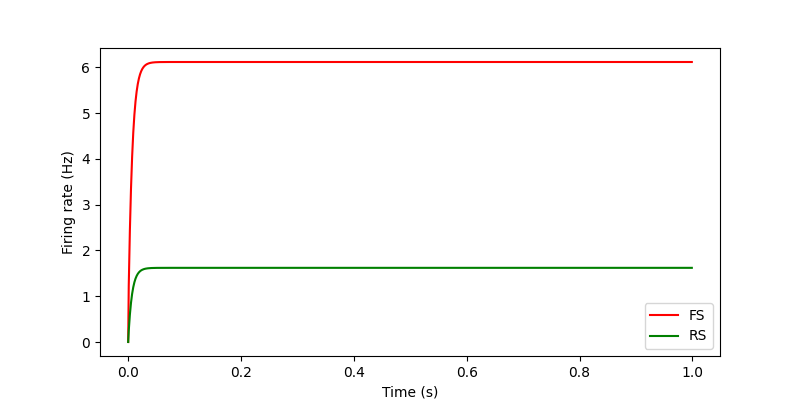

In [19]:
fig = plt.figure(figsize=(8,4))
for pop, color in zip(['FS','RS'], ['r','g']):
    plt.plot(time, rates[pop], label=pop, color=color)
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (Hz)")
plt.legend()
figs.append(fig)